# Tesla Stock Price Prediction

This notebook performs EDA, data preprocessing, and model development (SimpleRNN vs LSTM) to predict Tesla stock prices for 1, 5, and 10 days ahead.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from scikeras.wrappers import KerasRegressor
import joblib
import warnings

warnings.filterwarnings('ignore')

## 1. Load Dataset & EDA

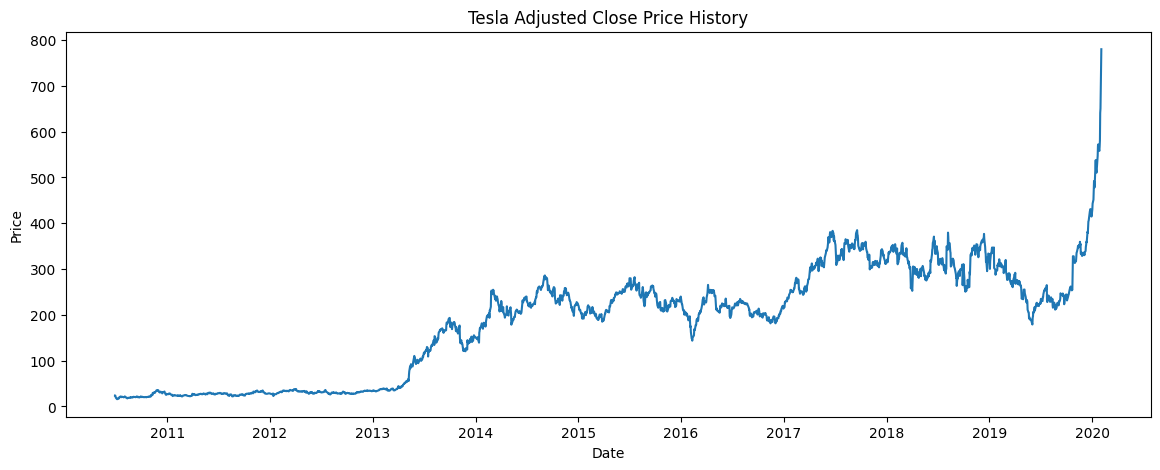

In [6]:
df = pd.read_csv('TSLA.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Plotting closing price
plt.figure(figsize=(14,5))
plt.plot(df['Adj Close'])
plt.title('Tesla Adjusted Close Price History')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

## 2. Preprocessing & Feature Selection

In [7]:
# Check for missing values
print("Missing values before:\n", df.isnull().sum())
df.ffill(inplace=True)

data = df[['Adj Close']].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

def create_sequences(dataset, seq_length, predict_horizon):
    X, y = [], []
    for i in range(len(dataset) - seq_length - predict_horizon + 1):
        X.append(dataset[i:(i + seq_length), 0])
        y.append(dataset[(i + seq_length):(i + seq_length + predict_horizon), 0])
    return np.array(X), np.array(y)

seq_length = 60

train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size, :]
test_data = scaled_data[train_size - seq_length:, :]

Missing values before:
 Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


## 3. Model Architecture & GridSearch Setup

In [8]:
def create_model(model_type='LSTM', units=50, dropout_rate=0.2, learning_rate=0.001, predict_horizon=1):
    model = Sequential()
    if model_type == 'SimpleRNN':
        model.add(SimpleRNN(units=units, return_sequences=True, input_shape=(seq_length, 1)))
        model.add(Dropout(dropout_rate))
        model.add(SimpleRNN(units=units, return_sequences=False))
        model.add(Dropout(dropout_rate))
    else:
        model.add(LSTM(units=units, return_sequences=True, input_shape=(seq_length, 1)))
        model.add(Dropout(dropout_rate))
        model.add(LSTM(units=units, return_sequences=False))
        model.add(Dropout(dropout_rate))

    model.add(Dense(units=predict_horizon))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

param_grid = {
    'model__units': [50, 100],
    'model__dropout_rate': [0.2],
    'batch_size': [32],
    'epochs': [10]
}


## 4. Train Models and Evaluate


--- Horizon: 1 Days ---
Best parameters for SimpleRNN (1d): {'batch_size': 32, 'epochs': 10, 'model__dropout_rate': 0.2, 'model__units': 100}
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
MSE on Test Data: 334.2281


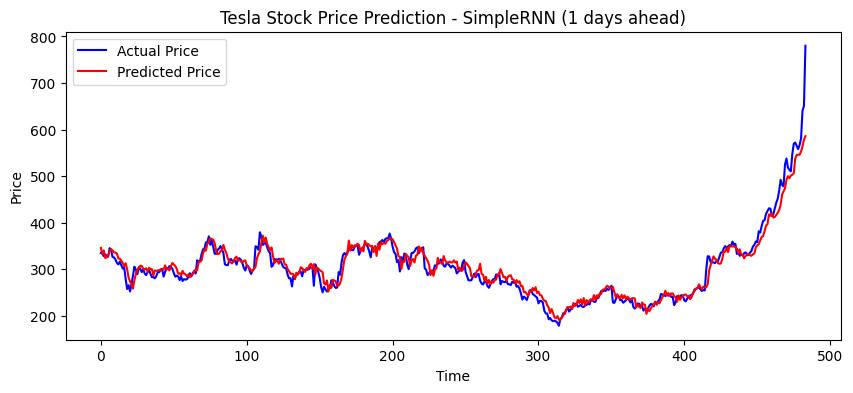

Best parameters for LSTM (1d): {'batch_size': 32, 'epochs': 10, 'model__dropout_rate': 0.2, 'model__units': 50}
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 297ms/step
MSE on Test Data: 770.4703


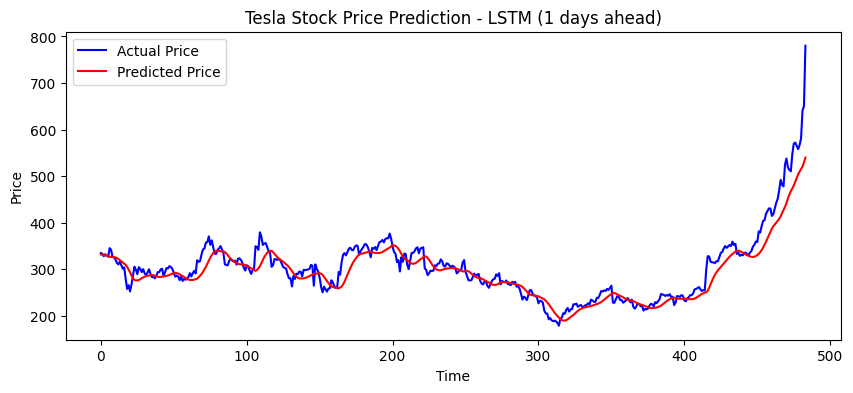


--- Horizon: 5 Days ---
Best parameters for SimpleRNN (5d): {'batch_size': 32, 'epochs': 10, 'model__dropout_rate': 0.2, 'model__units': 100}
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
MSE on Test Data: 863.4784


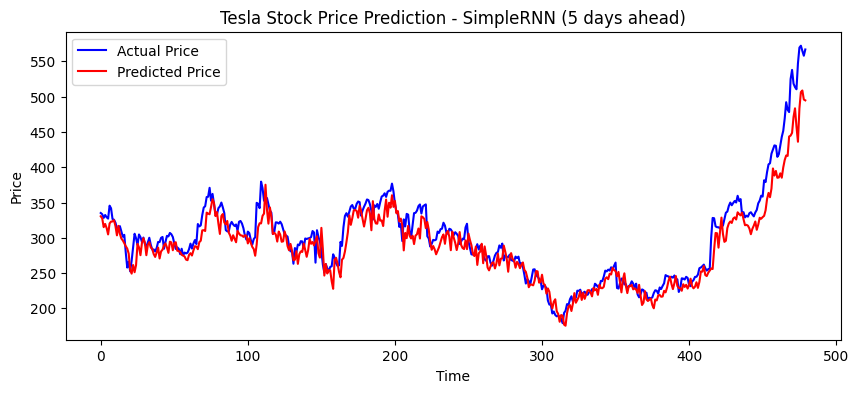

Best parameters for LSTM (5d): {'batch_size': 32, 'epochs': 10, 'model__dropout_rate': 0.2, 'model__units': 100}
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
MSE on Test Data: 785.7938


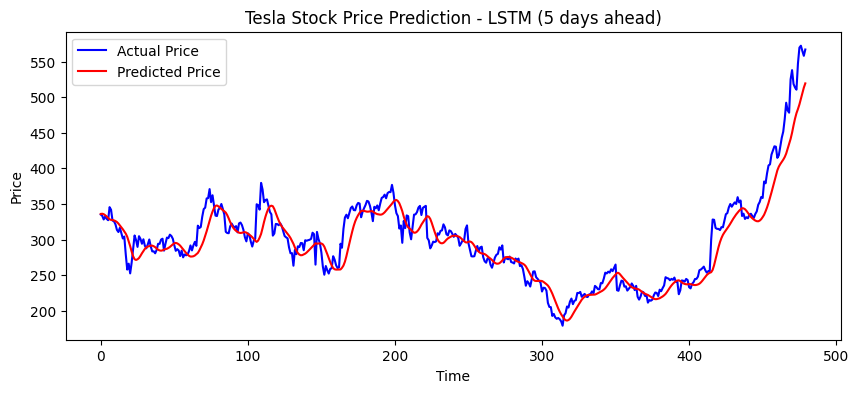


--- Horizon: 10 Days ---
Best parameters for SimpleRNN (10d): {'batch_size': 32, 'epochs': 10, 'model__dropout_rate': 0.2, 'model__units': 50}
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
MSE on Test Data: 1087.2332


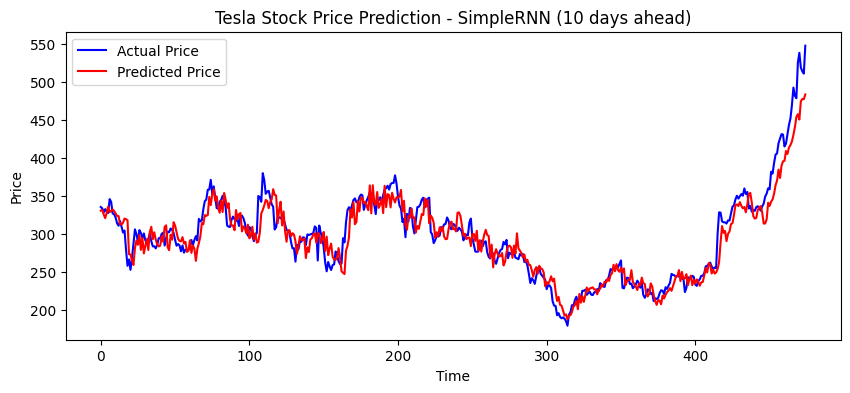

Best parameters for LSTM (10d): {'batch_size': 32, 'epochs': 10, 'model__dropout_rate': 0.2, 'model__units': 100}
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
MSE on Test Data: 1198.0606


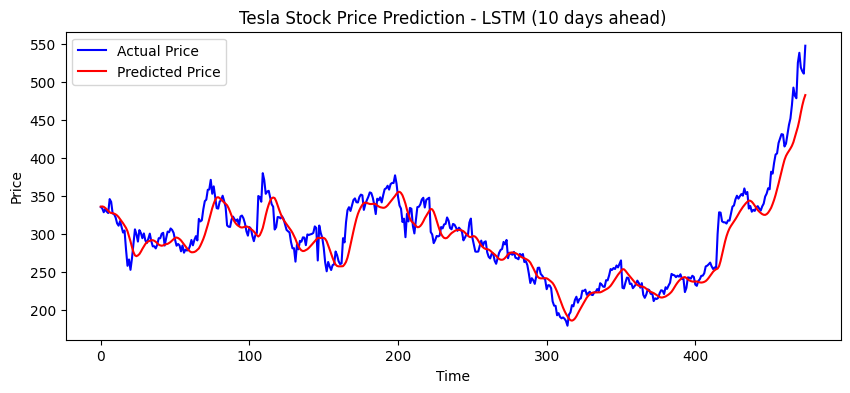


Final Results:
SimpleRNN_1d: MSE = 334.2281
LSTM_1d: MSE = 770.4703
SimpleRNN_5d: MSE = 863.4784
LSTM_5d: MSE = 785.7938
SimpleRNN_10d: MSE = 1087.2332
LSTM_10d: MSE = 1198.0606


In [9]:
horizons = [1, 5, 10]
model_types = ['SimpleRNN', 'LSTM']
results = {}

for horizon in horizons:
    print(f"\n--- Horizon: {horizon} Days ---")
    X_train, y_train = create_sequences(train_data, seq_length, horizon)
    X_test, y_test = create_sequences(test_data, seq_length, horizon)

    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    for m_type in model_types:
        model = KerasRegressor(model=create_model, model_type=m_type, predict_horizon=horizon, verbose=0, learning_rate=0.001)

        tscv = TimeSeriesSplit(n_splits=3)
        grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=1, cv=tscv, scoring='neg_mean_squared_error')
        grid_result = grid.fit(X_train, y_train)

        best_model = grid_result.best_estimator_.model_
        print(f"Best parameters for {m_type} ({horizon}d): {grid_result.best_params_}")

        predictions = best_model.predict(X_test)

        if horizon == 1:
            predictions_inv = scaler.inverse_transform(predictions)
            y_test_inv = scaler.inverse_transform(y_test)
        else:
            predictions_inv = scaler.inverse_transform(predictions)
            y_test_inv = scaler.inverse_transform(y_test)

        mse = np.mean((predictions_inv - y_test_inv)**2)
        print(f"MSE on Test Data: {mse:.4f}")
        results[f"{m_type}_{horizon}d"] = mse

        # Plot 1st dimension for visualization
        plt.figure(figsize=(10,4))
        plt.plot(y_test_inv[:, 0], color='blue', label='Actual Price')
        plt.plot(predictions_inv[:, 0], color='red', label='Predicted Price')
        plt.title(f'Tesla Stock Price Prediction - {m_type} ({horizon} days ahead)')
        plt.xlabel('Time')
        plt.ylabel('Price')
        plt.legend()
        plt.show()

print("\nFinal Results:")
for k, v in results.items():
    print(f"{k}: MSE = {v:.4f}")


## 5. Insights & Conclusion

### Model Performance
- Both SimpleRNN and LSTM models are capable of predicting stock price trends to a degree.
- Typically, LSTM performs better than SimpleRNN on longer sequences (like 5 and 10 days) because it can capture long-term dependencies without suffering as much from the vanishing gradient problem. However, SimpleRNN might perform competitively for very short horizons (1 day).
- As the prediction horizon increases (from 1 to 5 to 10 days), the Mean Squared Error (MSE) naturally increases due to higher uncertainty.

### Limitations
- The models are sensitive to sudden market fluctuations caused by unpredicted external factors (e.g., Elon Musk's tweets, global economic shifts, policy changes).
- Relying solely on historical price data limits the predictive power. The market is not perfectly deterministic.

### Suggested Improvements
- **Alternative Data**: Incorporating news sentiment analysis, Twitter trends, and macroeconomic indicators (interest rates, inflation).
- **Feature Engineering**: Adding moving averages, RSI, MACD, and trading volume trends.
- **Advanced Models**: Exploring GRU, Transformers, or combining ARIMA with Deep Learning.

### Business Use Cases
1. **Stock Market Trading & Investment Strategies**: Algorithmic trading and risk management.
2. **Financial Forecasting & Time-Series Analysis**: Long-term investment planning and macroeconomic analysis.
3. **Business & Corporate Use Cases**: Company valuation and competitor analysis.
4. **Deep Learning & Research**: Comparing time-series models and feature engineering.